# Diamonds.csv 데이터셋을 이용해서 가격 예측 모델 학습을 진행하고 평가 결과를 확인

=== 원본 데이터 shape ===
(53940, 11)

=== 'Unnamed: 0' 컬럼 제거 후 shape ===
(53940, 10)

=== 결측치 개수 확인 (처리 전) ===
carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

=== 결측치 개수 확인 (처리 후) ===
carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

=== x, y, z 중 0값을 가진 행 개수 ===
x=0: 8
y=0: 7
z=0: 20

오류값(x,y,z=0) 제거: (53940, 10) -> (53920, 10)

=== 중복행 개수: 113 ===
중복행 제거: (49304, 10) -> (49191, 10)

=== 인코딩 후 매핑 실패(NaN) 개수 확인 ===
cut_encoded        0
color_encoded      0
clarity_encoded    0
dtype: int64

=== 최종 전처리 완료 데이터 ===
(49191, 10)
   carat  depth  table  price     x     y     z  cut_encoded  color_encoded  \
0   0.23   61.5   55.0    326  3.95  3.98  2.43            4              5   
1   0.21   59.8   61.0    326  3.89  3.84  2.31            3              5   
2   0.29   62.4   58.0    334  4.20  4.23  2.63

/Users/shinsunbin/Documents/GitHub/shieldus_education/.venv-1/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.117984e+09, tolerance: 4.639e+07
  model = cd_fast.enet_coordinate_descent(


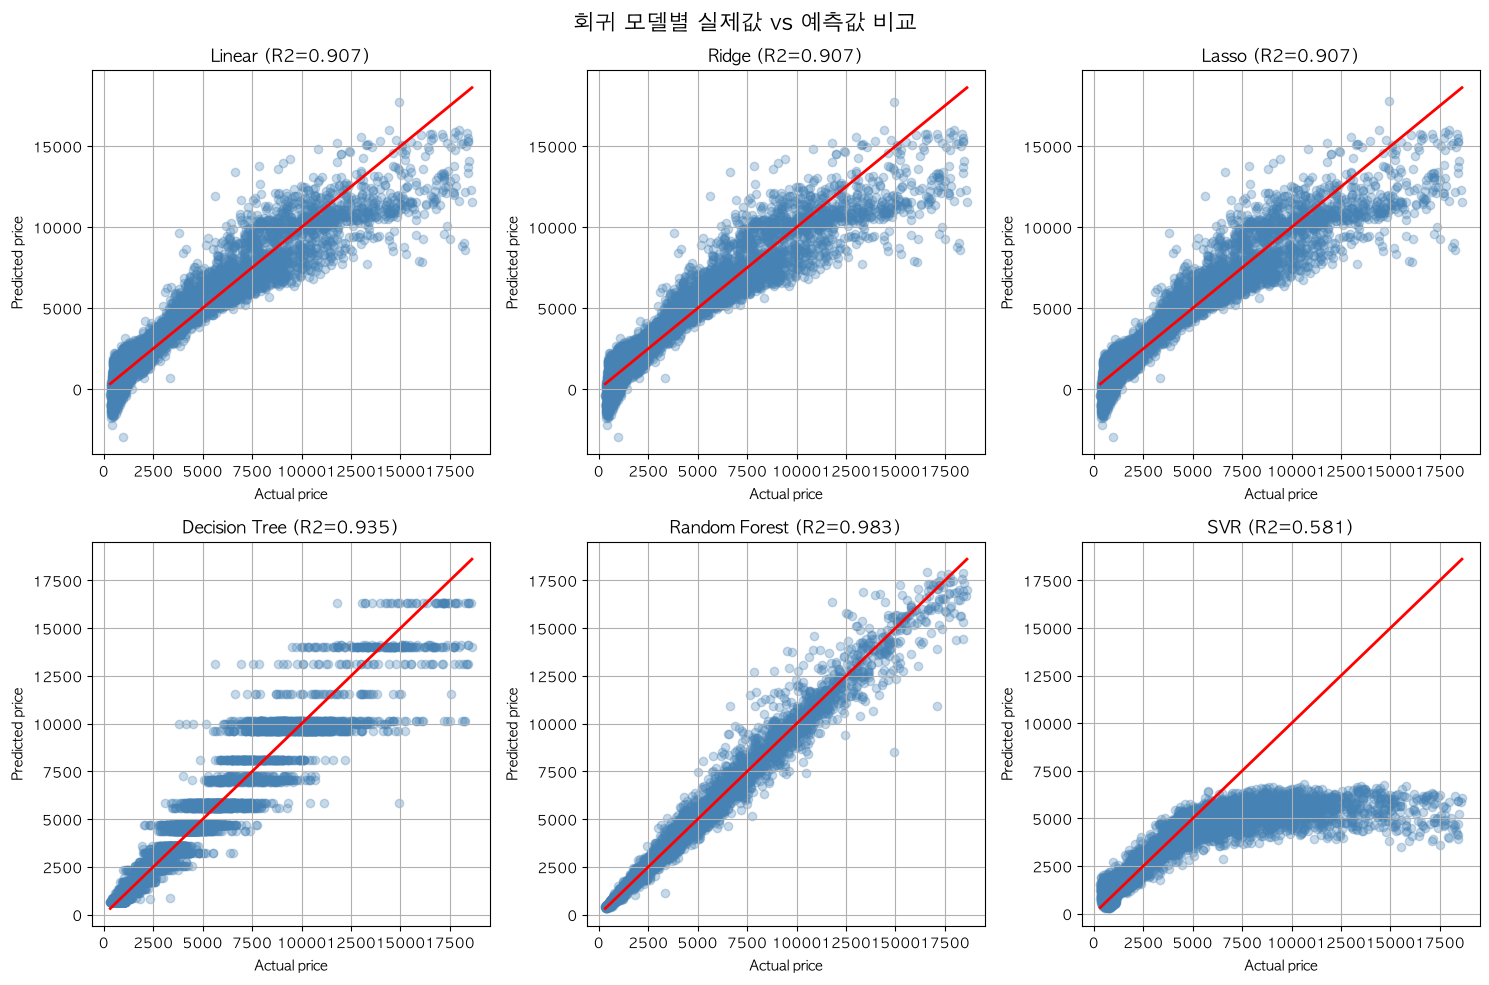

           Model          MAE           MSE         RMSE        R2
4  Random Forest   222.191547  1.972688e+05   444.149514  0.983207
3  Decision Tree   494.032939  7.653158e+05   874.823308  0.934852
0         Linear   705.958036  1.094697e+06  1046.277551  0.906813
1          Ridge   705.990090  1.094736e+06  1046.296115  0.906810
2          Lasso   705.763265  1.095056e+06  1046.449101  0.906783
5            SVR  1045.761580  4.927060e+06  2219.698238  0.580582

최종 모델
RandomForestRegressor(random_state=42)

최종 선택된 모델
모델 : Random Forest
R2   : 0.9832
RMSE : 444.15
MAE  : 222.19
MSE  : 197268.79

최종 선정 모델은 'Random Forest' 입니다. (R² = 0.9832)

=== 실제 가격 vs 예측 가격 (상위 10개) ===
   Actual Price  Predicted Price
0           574           579.58
1          1842          1736.73
2          4011          3964.07
3          3183          3396.28
4          2719          2698.42
5          2137          2303.99
6         10962         10381.89
7          1073          1066.55
8          5914     

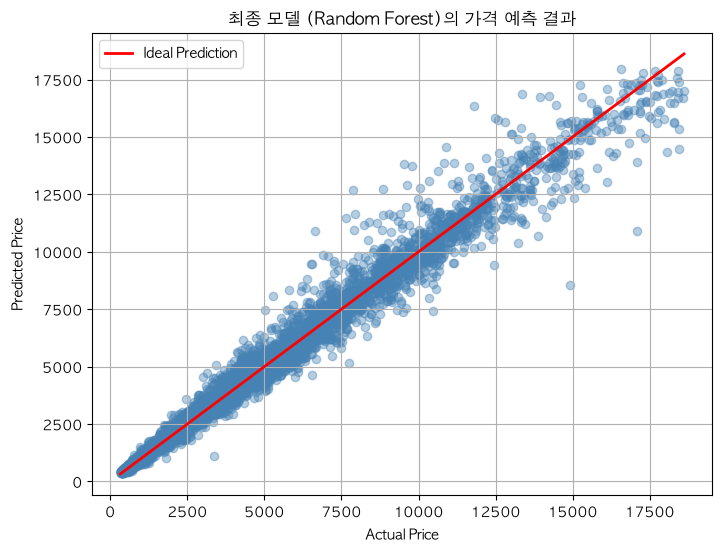

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

#데이터 불러오기
data = pd.read_csv('diamonds.csv')

# 한글 폰트 설정
# Windows
# plt.rcParams['font.family'] = 'Malgun Gothic'

# Mac 한글 폰트
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False


# 0. 데이터 로드
# 결측치/중복/오류값 정제 + 인코딩(변환) + 통합을 진행
df = pd.read_csv('diamonds.csv')
print("=== 원본 데이터 shape ===")
print(df.shape)


# 1. 불필요한 컬럼 제거
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
print("\n=== 'Unnamed: 0' 컬럼 제거 후 shape ===")
print(df.shape)


# 2. 결측치 처리
print("\n=== 결측치 개수 확인 (처리 전) ===")
print(df.isnull().sum())

numeric_cols = ['carat', 'depth', 'table', 'price', 'x', 'y', 'z']
categorical_cols = ['cut', 'color', 'clarity']

# 수치형: 평균 대체
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mean())

# 범주형: 최빈값 대체
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

print("\n=== 결측치 개수 확인 (처리 후) ===")
print(df.isnull().sum())


# 3. 오류값(논리적으로 불가능한 값) 수정
print("\n=== x, y, z 중 0값을 가진 행 개수 ===")
print("x=0:", (df['x'] == 0).sum())
print("y=0:", (df['y'] == 0).sum())
print("z=0:", (df['z'] == 0).sum())

before_shape = df.shape
df = df[(df['x'] > 0) & (df['y'] > 0) & (df['z'] > 0)]
print(f"\n오류값(x,y,z=0) 제거: {before_shape} -> {df.shape}")

# 3-1. 이상치(Outlier) 처리 - IQR 방식
outlier_cols = ['carat', 'depth', 'table', 'x', 'y', 'z']
outlier_mask = pd.Series(True, index=df.index)
for col in outlier_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outlier_mask &= (df[col] >= lower_bound) & (df[col] <= upper_bound)
df = df[outlier_mask]

# 4. 중복값 제거
dup_count = df.duplicated().sum()
print(f"\n=== 중복행 개수: {dup_count} ===")

before_shape = df.shape
df = df.drop_duplicates()
print(f"중복행 제거: {before_shape} -> {df.shape}")

# 인덱스가 중간중간 빠졌으므로 재정렬
df = df.reset_index(drop=True)


# 5. 범주형 데이터 변환 (인코딩)
cut_order = {'Fair': 0, 'Good': 1, 'Very Good': 2, 'Premium': 3, 'Ideal': 4}
color_order = {'J': 0, 'I': 1, 'H': 2, 'G': 3, 'F': 4, 'E': 5, 'D': 6}
clarity_order = {'I1': 0, 'SI2': 1, 'SI1': 2, 'VS2': 3, 'VS1': 4,
                  'VVS2': 5, 'VVS1': 6, 'IF': 7}

df['cut_encoded'] = df['cut'].map(cut_order)
df['color_encoded'] = df['color'].map(color_order)
df['clarity_encoded'] = df['clarity'].map(clarity_order)

# 매핑 후 혹시 매칭되지 않은 값(오타 등)이 있는지 확인
print("\n=== 인코딩 후 매핑 실패(NaN) 개수 확인 ===")
print(df[['cut_encoded', 'color_encoded', 'clarity_encoded']].isnull().sum())

# 매핑되지 않은 행(오타/미정의 범주)이 있다면 제거
df = df.dropna(subset=['cut_encoded', 'color_encoded', 'clarity_encoded'])


# 6. 데이터 통합 (feature 통합)
df_processed = df.drop(columns=['cut', 'color', 'clarity'])

print("\n=== 최종 전처리 완료 데이터 ===")
print(df_processed.shape)
print(df_processed.head())

# 7. 학습용 X, y 분리
X = df_processed.drop(columns=['price']).values
y = df_processed['price'].values

# 8. 피처 스케일링
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 9. 데이터 분리 (train/test)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42
)

# 10. 사용할 회귀 모델들 정의
models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.1),
    "Decision Tree": DecisionTreeRegressor(max_depth=5, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "SVR": SVR()
}

# 11. 학습 및 예측 결과 저장
results = []
trained_models = {}

n_models = len(models)
n_cols = 3
n_rows = int(np.ceil(n_models / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 10))
axes = axes.flatten()

for idx, (name, model) in enumerate(models.items()):
    model.fit(X_train, y_train)
    trained_models[name]=model
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append({
        'Model': name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2
    })

    # 실제값 vs 예측값 산점도
    ax = axes[idx]
    ax.scatter(y_test, y_pred, alpha=0.3, color='steelblue')
    # 완벽 예측 기준선 (y = x)
    min_val, max_val = y_test.min(), y_test.max()
    ax.plot([min_val, max_val], [min_val, max_val], color='red', linewidth=2)
    ax.set_title(f"{name} (R2={r2:.3f})")
    ax.set_xlabel("Actual price")
    ax.set_ylabel("Predicted price")
    ax.grid(True)

# 남는 서브플롯(모델 개수가 격자보다 적을 경우) 숨기기
for j in range(idx + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle("회귀 모델별 실제값 vs 예측값 비교", fontsize=16)
plt.tight_layout()
plt.show()


# 12. 모델 성능 비교
df_results = pd.DataFrame(results).sort_values(by='R2', ascending=False)

print(df_results)

best_model_name = df_results.iloc[0]['Model']
best_model = trained_models[best_model_name]

print("\n최종 모델")
print(best_model)

# R2 기준 최종 모델 선정
best_model_name = df_results.iloc[0]['Model']
best_r2 = df_results.iloc[0]['R2']
best_rmse = df_results.iloc[0]['RMSE']
best_mae = df_results.iloc[0]['MAE']
best_mse = df_results.iloc[0]['MSE']

print("\n====================================")
print("최종 선택된 모델")
print("====================================")
print(f"모델 : {best_model_name}")
print(f"R2   : {best_r2:.4f}")
print(f"RMSE : {best_rmse:.2f}")
print(f"MAE  : {best_mae:.2f}")
print(f"MSE  : {best_mse:.2f}")
print("====================================")

print(f"\n최종 선정 모델은 '{best_model_name}' 입니다. (R² = {best_r2:.4f})")

#13. 최종 모델의 가격 예측 결과 확인
# 테스트 데이터에 대해 가격 예측
final_pred = best_model.predict(X_test)

# 실제 가격과 예측 가격 비교
compare_df = pd.DataFrame({
    'Actual Price': y_test,
    'Predicted Price': np.round(final_pred, 2)
})

print("\n=== 실제 가격 vs 예측 가격 (상위 10개) ===")
print(compare_df.head(10))

# 예측 결과 시각화
plt.figure(figsize=(8,6))
plt.scatter(y_test, final_pred, alpha=0.4, color='steelblue')

min_val = min(y_test.min(), final_pred.min())
max_val = max(y_test.max(), final_pred.max())

plt.plot([min_val, max_val], [min_val, max_val],
         color='red', linewidth=2, label='Ideal Prediction')

plt.title(f"최종 모델 ({best_model_name})의 가격 예측 결과")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.legend()
plt.grid(True)
plt.show()